In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## **Data preprocessing**

In [2]:
data = pd.read_csv('data_1.csv')
data.head()

,Date Time,CO2 (ppm),Temperature (C),Humidity (%)
0,11/3/23 18:45,958,28.24,25.11
1,11/3/23 18:46,939,27.83,25.63
2,11/3/23 18:47,928,27.53,26.00
3,11/3/23 18:48,927,27.34,26.38
4,11/3/23 18:49,928,27.08,26.77


In [3]:
data.value_counts()

Date Time      CO2 (ppm)  Temperature (C)  Humidity (%)
11/3/23 18:45  958        28.24            25.11           1
11/4/23 06:02  960        23.86            63.32           1
11/4/23 05:49  962        23.86            60.77           1
11/4/23 05:50  962        23.86            60.78           1
11/4/23 05:51  962        23.86            60.82           1
                                                          ..
11/4/23 00:25  734        22.92            53.62           1
11/4/23 00:26  734        22.92            53.70           1
11/4/23 00:27  736        22.92            53.99           1
11/4/23 00:28  738        22.92            54.28           1
11/4/23 11:32  901        24.37            57.98           1
Name: count, Length: 1008, dtype: int64

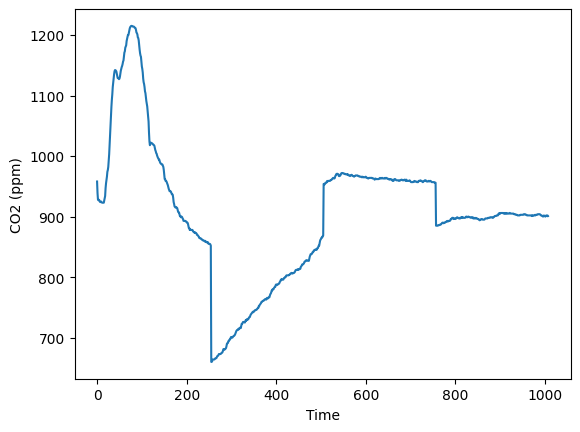

In [4]:
plt.plot(data["CO2 (ppm)"])
plt.xlabel("Time")
plt.ylabel("CO2 (ppm)")
plt.show()

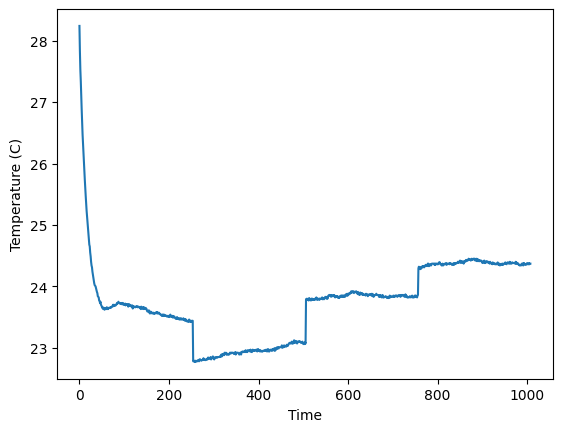

In [5]:
plt.plot(data["Temperature (C)"])
plt.xlabel("Time")
plt.ylabel("Temperature (C)")
plt.show()

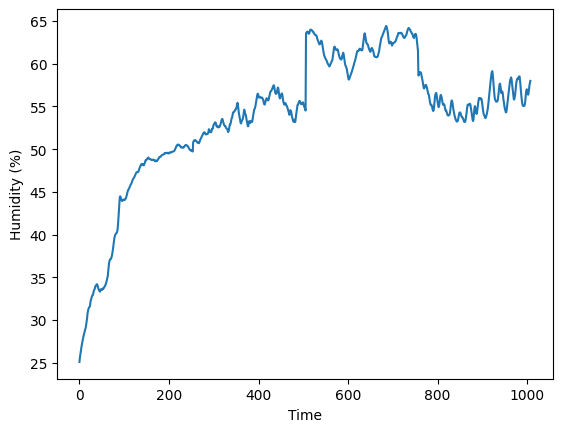

In [6]:
plt.plot(data["Humidity (%)"])
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.show()

In [7]:
### Normalization ###
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
new_data = data.drop(columns=["Date Time"])
data_scaled = scaler.fit_transform(new_data)
data_scaled = pd.DataFrame(data_scaled, columns=new_data.columns)
data_scaled.head()

,CO2 (ppm),Temperature (C),Humidity (%)
0,0.536937,1.000000,0.000000
1,0.502703,0.925046,0.013232
2,0.482883,0.870201,0.022646
3,0.481081,0.835466,0.032316
4,0.482883,0.787934,0.042239


In [8]:
X = data_scaled["Humidity (%)"].values
X.shape

(1008,)

In [9]:
## without normalization ##
# X = data["Humidity (%)"].values
# X.shape

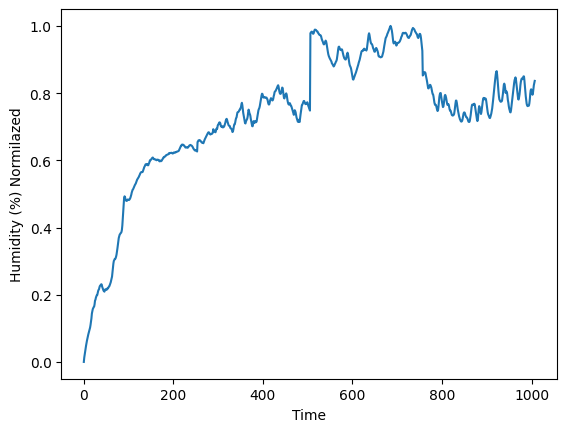

In [10]:
plt.plot(X)
plt.xlabel("Time")
plt.ylabel("Humidity (%) Normilazed")
plt.show()

In [11]:
### Prepare the data for RNN ###
def create_dataset(X, time_step=3):
    Xs = []
    ys = []
    for i in range(len(X) - time_step - 1):
        Xs.append(X[i:(i + time_step)])
        ys.append(X[i + time_step])
    return np.array(Xs), np.array(ys)


In [12]:
X_data, y_data = create_dataset(X, time_step=3)
X_data.shape, y_data.shape

((1004, 3), (1004,))

In [13]:
### split tha data into train and test ###
train_size = int(len(X_data) * 0.8)
test_size = len(X_data) - train_size
X_train, X_test = X_data[0:train_size], X_data[train_size:len(X_data)]
y_train, y_test = y_data[0:train_size], y_data[train_size:len(y_data)]
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((803, 3), (201, 3), (803,), (201,))

## **Prediction with Linear Regression**

In [14]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_LR_pred = model.predict(X_test.reshape(-1, 3))

In [15]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_LR_pred)
print("Linear Regression MSE:", mse)

Linear Regression MSE: 4.4440457867728617e-05


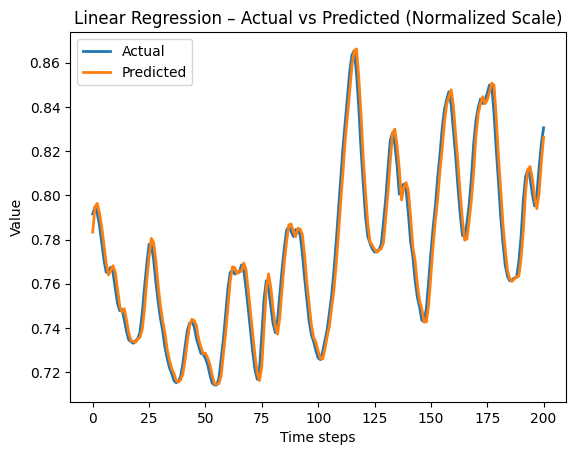

In [16]:
plt.plot(y_test, label="Actual", linewidth=2)
plt.plot(y_LR_pred, label="Predicted", linewidth=2)
plt.xlabel("Time steps")
plt.ylabel("Value")
plt.title("Linear Regression – Actual vs Predicted (Normalized Scale)")
plt.legend()
plt.show()

## **RNN Model building and training**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# Initialize RNN parameters
# Single-cell RNN
# ------------------------------------------
w_x = np.random.randn(1, 1) * 0.1      # input → hidden
w_h = np.random.randn(1, 1) * 0.1      # hidden → hidden
b_h = np.zeros((1, 1))

w_y = np.random.randn(1, 1) * 0.1      # hidden → output
b_y = np.zeros((1, 1))

learning_rate = 0.01
epochs = 100

loss_history = []

# ------------------------------------------
# Training loop
# ------------------------------------------
for epoch in range(epochs):
    epoch_loss = 0

    for i in range(X_train.shape[0]):
        x_seq = X_train[i]      # shape (3,)
        y_true = y_train[i]

        # Store states for backprop
        hs = {}         # hidden states
        hs[-1] = np.zeros((1, 1))   # h_prev
        xs = {}         # inputs
        ys = {}         # outputs

        # ----------------------
        # Forward pass (3 steps)
        # ----------------------
        for t in range(3):
            xs[t] = np.array([[x_seq[t]]])  # reshape (1,1)

            h_t = np.tanh(np.dot(w_x, xs[t]) + np.dot(w_h, hs[t-1]) + b_h)
            hs[t] = h_t

        # Final output
        y_pred = np.dot(w_y, hs[2]) + b_y
        ys = y_pred

        # Loss (MSE)
        loss = 0.5 * (y_pred - y_true)**2
        epoch_loss += loss

        # ----------------------
        # Backward pass
        # ----------------------

        # dL/dy_pred
        dy = (y_pred - y_true)     # shape (1,1)

        # Gradients for output layer
        dw_y = dy * hs[2]
        db_y = dy

        # Backprop into h (start from last time step)
        dh = np.dot(w_y.T, dy)      # (1,1)

        # Initialize RNN grads
        dw_x = np.zeros_like(w_x)
        dw_h = np.zeros_like(w_h)
        db_h = np.zeros_like(b_h)

        # Backprop through time
        for t in reversed(range(3)):
            h_t = hs[t]
            dh_raw = dh * (1 - h_t**2)   # derivative of tanh

            dw_x += np.dot(dh_raw, xs[t].T)
            dw_h += np.dot(dh_raw, hs[t-1].T)
            db_h += dh_raw

            dh = np.dot(w_h.T, dh_raw)

        # ----------------------
        # Update parameters
        # ----------------------
        w_x -= learning_rate * dw_x
        w_h -= learning_rate * dw_h
        b_h -= learning_rate * db_h

        w_y -= learning_rate * dw_y
        b_y -= learning_rate * db_y

    # Store average epoch loss
    loss_history.append(epoch_loss / X_train.shape[0])
    print(f"Epoch {epoch+1}/{epochs}, Loss = {loss_history[-1][0][0]:.6f}")



In [ ]:
len(loss_history)

In [ ]:
np.array(loss_history).shape

In [ ]:
# ------------------------------------------
# Plot loss curve
# ------------------------------------------
plt.plot(np.array(loss_history).reshape(-1))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

## **Model testing**

In [ ]:
# ----------------------------------------
# Predict function (no classes, no methods)
# ----------------------------------------
y_pred_test = []

for i in range(X_test.shape[0]):
    x_seq = X_test[i]   # shape (3,)
    
    h_prev = np.zeros((1,1))   # reset hidden state for each sequence
    
    # Forward pass through the 3 time steps
    for t in range(3):
        x_t = np.array([[x_seq[t]]])  # reshape to (1,1)
        h_prev = np.tanh(np.dot(w_x, x_t) + np.dot(w_h, h_prev) + b_h)

    # Final output
    y_hat = np.dot(w_y, h_prev) + b_y
    y_pred_test.append(float(y_hat))

y_pred_test = np.array(y_pred_test)

# ----------------------------------------
# Plot predictions vs actual values
# ----------------------------------------
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual", linewidth=2)
plt.plot(y_pred_test, label="Predicted", linewidth=2)
plt.title("Test Set: Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Humidity (%) Normilated")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred_test)
print(f"Test MSE: {mse:.6f}")

In [ ]:
## Inversing the normalization
y_test = y_test.reshape(-1,1)
y_pred_test = y_pred_test.reshape(-1,1)
y_test_inv = scaler.inverse_transform(np.hstack((np.zeros((y_test.shape[0], data_scaled.shape[1]-1)), y_test)))
y_pred_inv = scaler.inverse_transform(np.hstack((np.zeros((y_pred_test.shape[0], data_scaled.shape[1]-1)), y_pred_test)))
plt.figure(figsize=(10,5))
plt.plot(y_test_inv[:, -1], label="Actual", linewidth=2)
plt.plot(y_pred_inv[:, -1], label="Predicted", linewidth=2)
plt.title("Test Set: Actual vs Predicted (Inversed)")
plt.xlabel("Time Steps")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()

## **Vectorized version of RNN model**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# Initialize RNN parameters (same as yours)
# ------------------------------------------
w_x = np.random.randn(1, 1) * 0.1
w_h = np.random.randn(1,  1) * 0.1
b_h = np.zeros((1, 1))

w_y = np.random.randn(1, 1) * 0.1
b_y = np.zeros((1, 1))

learning_rate = 0.001
epochs = 100

loss_history = []

# ------------------------------------------
# Vectorized Training Loop
# ------------------------------------------
N = X_train.shape[0]
seq_len = 3

for epoch in range(epochs):

    # Containers for forward pass
    xs = np.zeros((N, seq_len, 1))          # inputs
    hs = np.zeros((N, seq_len + 1, 1))      # hidden states

    # ---------------------
    # Forward pass
    # ---------------------
    for t in range(seq_len):
        xs[:, t, 0] = X_train[:, t]               # (N,1)

        x_t = xs[:, t].reshape(N, 1, 1)           # (N,1,1)
        h_prev = hs[:, t].reshape(N, 1, 1)        # (N,1,1)

        # h_t = tanh(w_x * x_t + w_h * h_prev + b_h)
        h_t = np.tanh(
            w_x @ x_t.transpose(0,2,1) +          # (1,1)*(N,1,1)
            w_h @ h_prev +                        # (1,1)*(N,1,1)
            b_h                                   # (1,1)
        )

        hs[:, t+1] = h_t.reshape(N, 1)

    # Output (vectorized)
    y_pred = (w_y @ hs[:, -1].reshape(N, 1, 1) + b_y).reshape(N)

    # Loss (mean)
    loss = 0.5 * np.mean((y_pred - y_train)**2)
    loss_history.append(loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss = {loss:.6f}")

    # ---------------------
    # Backward pass
    # ---------------------

    # dL/dy
    dy = (y_pred - y_train).reshape(N, 1, 1)     # (N,1,1)

    # Output layer gradients
    dw_y = np.sum(dy * hs[:, -1].reshape(N, 1, 1).transpose(0,2,1), axis=0)
    db_y = np.sum(dy, axis=0)

    # Backprop into last hidden h
    dh = w_y.T @ dy    # (1,1)*(N,1,1) -> (N,1,1)

    # Initialize grads for RNN
    dw_x = np.zeros_like(w_x)
    dw_h = np.zeros_like(w_h)
    db_h = np.zeros_like(b_h)

    # BPTT: back through 3 time steps
    dh_t = dh
    for t in reversed(range(seq_len)):
        h_t = hs[:, t+1].reshape(N, 1, 1)
        h_prev = hs[:, t].reshape(N, 1, 1)
        x_t = xs[:, t].reshape(N, 1, 1)

        # derivative tanh
        dh_raw = dh_t * (1 - h_t**2)

        # accumulate grads
        dw_x += np.sum(dh_raw @ x_t.transpose(0,2,1), axis=0)
        dw_h += np.sum(dh_raw @ h_prev.transpose(0,2,1), axis=0)
        db_h += np.sum(dh_raw, axis=0)

        dh_t = w_h.T @ dh_raw

    # ---------------------
    # Update parameters
    # ---------------------
    w_x -= learning_rate * dw_x
    w_h -= learning_rate * dw_h
    b_h -= learning_rate * db_h

    w_y -= learning_rate * dw_y
    b_y -= learning_rate * db_y


In [ ]:
import numpy as np
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
# X_test shape: (N, T, D)
N, T, D = X_test.shape
H = w_h.shape[0]       # hidden size

# hidden state
h = np.zeros((N, H))

# forward RNN pass (vectorized)
for t in range(T):
    x_t = X_test[:, t, :]                     # (N, D)
    h = np.tanh(x_t @ w_x + h @ w_h + b_h)  # (N, H)

# final output
y_pred_scaled = h @ w_y + b_y               # (N, 1)
y_pred_test = y_pred_scaled.reshape(-1)
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual", linewidth=2)
plt.plot(y_pred_test, label="Predicted", linewidth=2)
plt.title("Vectorized RNN – Actual vs Predicted (Normalized Scale)")
plt.xlabel("Time steps")
plt.ylabel("Humidity (%) Normilated")
plt.legend()
plt.grid(True)
plt.show()


## **Multi-Cell RNN**

In [ ]:
import numpy as np

# ---------------------------------------------------------
# Dataset shapes
# ---------------------------------------------------------
# X_train: (N, 3)
# y_train: (N,)
N = X_train.shape[0]
seq_len = 3

# ---------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------
hidden_size = 4       # <-- increase this to add more RNN cells!
learning_rate = 0.001
epochs = 100

# ---------------------------------------------------------
# Initialize weights (vectorized)
# ---------------------------------------------------------
w_x = np.random.randn(hidden_size, 1) * 0.1       # (H, 1)
w_h = np.random.randn(hidden_size, hidden_size) * 0.1   # (H, H)
b_h = np.zeros((hidden_size, 1))                  # (H, 1)

w_y = np.random.randn(1, hidden_size) * 0.1       # (1, H)
b_y = np.zeros((1, 1))                            # (1, 1)

loss_history = []


# ---------------------------------------------------------
# TRAINING (Vectorized)
# ---------------------------------------------------------
for epoch in range(epochs):

    # Forward state containers
    Hs = np.zeros((N, seq_len + 1, hidden_size))  # hidden states
    Xs = np.zeros((N, seq_len, 1))                # input x_t

    # ----- FORWARD PASS -----
    for t in range(seq_len):
        Xs[:, t, 0] = X_train[:, t]

        x_t = Xs[:, t].reshape(N, 1, 1)           # (N, 1, 1)

        h_prev = Hs[:, t].reshape(N, hidden_size, 1)

        # Vectorized hidden state update
        h_t = np.tanh(
            w_x @ x_t.transpose(0,2,1) +      # (H,1) × (N,1,1) -> (N,H,1)
            w_h @ h_prev +                    # (H,H) × (N,H,1)
            b_h                               # (H,1)
        )

        Hs[:, t+1] = h_t.reshape(N, hidden_size)

    # Final output
    h_final = Hs[:, -1].reshape(N, hidden_size, 1)        # (N,H,1)
    y_pred = (w_y @ h_final + b_y).reshape(N)             # (N,)

    # Loss
    loss = 0.5 * np.mean((y_pred - y_train)**2)
    loss_history.append(loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss = {loss:.6f}")

    # ----- BACKWARD PASS -----
    dy = (y_pred - y_train).reshape(N, 1, 1)              # (N,1,1)

    # Output layer gradients
    dw_y = np.sum(dy @ h_final.transpose(0,2,1), axis=0)  # (1,H)
    db_y = np.sum(dy, axis=0)                             # (1,1)

    # Backprop into h
    dh = w_y.T @ dy                                       # (H,1) × (N,1,1) -> (N,H,1)

    # Initialize RNN param grads
    dw_x = np.zeros_like(w_x)
    dw_h = np.zeros_like(w_h)
    db_h = np.zeros_like(b_h)

    # BPTT through time (t = 2,1,0)
    dh_t = dh
    for t in reversed(range(seq_len)):

        h_t = Hs[:, t+1].reshape(N, hidden_size, 1)
        h_prev = Hs[:, t].reshape(N, hidden_size, 1)

        # derivative of tanh
        dh_raw = dh_t * (1 - h_t**2)

        # accumulate gradients
        x_t = Xs[:, t].reshape(N, 1, 1)
        dw_x += np.sum(dh_raw @ x_t.transpose(0,2,1), axis=0)
        dw_h += np.sum(dh_raw @ h_prev.transpose(0,2,1), axis=0)
        db_h += np.sum(dh_raw, axis=0)

        dh_t = w_h.T @ dh_raw

    # Parameter update
    w_x -= learning_rate * dw_x
    w_h -= learning_rate * dw_h
    b_h -= learning_rate * db_h
    w_y -= learning_rate * dw_y
    b_y -= learning_rate * db_y


In [ ]:
plt.plot(loss_history)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Vectorized RNN Prediction on Test Set
# ----------------------------------------

N_test = X_test.shape[0]
seq_len = 3

# Containers
Hs_test = np.zeros((N_test, seq_len + 1, hidden_size))   # hidden states
Xs_test = np.zeros((N_test, seq_len, 1))                 # inputs

# -------------------------
# FORWARD PASS FOR TEST SET
# -------------------------
for t in range(seq_len):
    print(Xs_test.shape)
#     Xs_test[:, t, 0] = X_test[:, t]      # shape (N_test,1)

#     x_t = Xs_test[:, t].reshape(N_test, 1, 1)             # (N_test,1,1)
#     h_prev = Hs_test[:, t].reshape(N_test, hidden_size, 1)

#     h_t = np.tanh(
#         w_x @ x_t.transpose(0,2,1) +
#         w_h @ h_prev +
#         b_h
#     )

#     Hs_test[:, t+1] = h_t.reshape(N_test, hidden_size)

# # Final output (vectorized)
# h_final_test = Hs_test[:, -1].reshape(N_test, hidden_size, 1)
# y_pred_test = (w_y @ h_final_test + b_y).reshape(N_test)

# print("Predictions computed!")

# # ----------------------------------------
# # Plot Actual vs Predicted
# # ----------------------------------------
# plt.figure(figsize=(10,5))
# plt.plot(y_test, label="Actual", linewidth=2)
# plt.plot(y_pred_test, label="Predicted", linewidth=2)
# plt.xlabel("Time steps")
# plt.ylabel("Value")
# plt.title("Vectorized RNN – Actual vs Predicted (Normalized Scale)")
# plt.legend()
# plt.grid(True)
# plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred_test)
print(f"Test MSE: {mse:.6f}")

## **RNN using PyTorch**

In [ ]:
import torch
# Convert numpy → torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).reshape(-1, 3, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32).reshape(-1, 3, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class SimpleRNN(nn.Module):
    def __init__(self):
        super(SimpleRNN, self).__init__()
        
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=4,   # 4 RNN cells
            num_layers=1,
            batch_first=True
        )
        
        self.fc = nn.Linear(4, 1)  # map last hidden state → output

    def forward(self, x):
        out, h = self.rnn(x)
        last_output = out[:, -1, :]   # last time step output
        y = self.fc(last_output)
        return y


In [ ]:
model = SimpleRNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
model.to(device)
epochs = 200
loss_history = []

for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    y_pred = model(X_train_t.to(device))
    
    loss = criterion(y_pred, y_train_t.to(device))
    loss.backward()
    
    optimizer.step()
    
    loss_history.append(loss.item())
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")


In [ ]:
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()


In [ ]:
model.eval()

with torch.no_grad():
    model.to("cpu")
    y_pred_test = model(X_test_t)

y_pred_test = y_pred_test.numpy().flatten()
y_actual = y_test.flatten()


In [ ]:
plt.figure(figsize=(7,4))
plt.plot(y_actual, label="Actual")
plt.plot(y_pred_test, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (RNN with 4 cells)")
plt.grid(True)
plt.show()


## **LSTM Implemetation**